# Calibrating against real scores

Every number in this project so far describes a **simulated** player. The model has grown a
size, a shape, a pull and a lean, and each addition was justified by measuring what ignoring
it costs -- but always against a thrower we invented, whose parameters we knew because we
chose them.

This notebook is the preparation for pointing it at a real one. No real data is used here;
none is needed yet. The questions that come *before* the data are the ones this project is
usually good at:

1. **Can the aim be recovered from a scoresheet at all?** A match record says a visit scored
   140, not where the darts were thrown. Without an aim point there is nothing to fit.
2. **What would the data buy?** How many darts of match play measure a player, and to what
   precision.
3. **What does the model predict that could be *wrong*?** A calibration that can only
   succeed is not a test. The useful output is a prediction sharp enough to fail.

The third is the point. The model has one parameter for a player's scoring and it must
explain their three-dart average, their 180 rate and their checkout percentage
*simultaneously*. There is no reason it should.

In [1]:
import os
import sys
import time
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts.calibration import (SCORING_FLOOR, T20_MM, DoubleAttempts,
                               ScoringVisits, aggregate_consistency,
                               fit_from_visits, scoring_floor)
from darts.dartboards import generate_dartboard
from darts.utils import mm_per_pixel

PX = 512
BOARD, CHECKOUTS = generate_dartboard(PX)
MM = mm_per_pixel(PX)
CENTRE = PX // 2
RESULTS = os.path.join(module_path, 'results', 'calibration')

SV = ScoringVisits(board_pixels=PX, board=BOARD)
DA = DoubleAttempts(board_pixels=PX, board=BOARD, checkouts=CHECKOUTS)
print(f'board {PX}px, scoring floor {SCORING_FLOOR}')

board 512px, scoring floor 250


## 1. Where the aim is knowable

A scoresheet has no aim point, and inferring one from the policy is circular: the policy
depends on $\sigma$, which is what we are trying to estimate.

There is one region where the circularity does not arise. While the remaining score is high
enough that no checkout is in reach, the optimal aim is the **treble 20** for every ability
this project models -- and so is what every real player does, which matters more. The aim is
then *known*, not inferred, and three further things follow:

* all three darts of a visit go at the same point, so they are **i.i.d.**;
* a dart thrown at 62 or more cannot bust, so no visit is truncated;
* therefore the **visit total is the three-fold convolution** of one dart's score
  distribution.

That last point is what makes a per-visit scoresheet -- the granularity real data actually
comes in -- directly usable, with an exact likelihood, without ever knowing which dart
scored what.

The region is not the whole scoring phase, and the boundary is worth deriving rather than
guessing.

In [2]:
t0 = time.perf_counter()
floor = scoring_floor(sigmas=(6.5, 8.0, 10.0, 13.0), board_pixels=PX)
print(f'derived floor: {floor}   ({time.perf_counter()-t0:.0f}s)')

derived floor: 250   (39s)


In [3]:
# where does the aim leave the treble 20, and what does forcing it back cost?
from darts.mdp_3turn import ThreeDartMDP
from darts.transitions import transition_arrays
from darts.utils import aim_description

rows = []
for s in (6.5, 8.0, 10.0, 13.0):
    tr = transition_arrays(PX, s, margin_mm=10.0, point_stride=4)
    m = ThreeDartMDP(tr['probs'], tr['checkout_probs'], tr['allowed_scores'], 501,
                     dart_cost=0.0, turn_cost=1.0).solve()
    lab = np.array([aim_description(p, PX) for p in tr['points']])
    t20 = int(np.flatnonzero(lab == 'T20')[0])
    for dart in (1, 2, 3):
        hi = None
        for score in range(182, 502):
            q = m.q_values(score, dart, max(score, 182))
            a = int(np.argmax(q))
            if lab[a] != 'T20' and (hi is None or score > hi[0]):
                hi = (score, lab[a], q[a] - q[t20])
        rows.append({'sigma': s, 'dart': dart,
                     'highest non-T20 score': hi[0] if hi else None,
                     'what it prefers': hi[1] if hi else '-',
                     'cost of forcing T20 (visits)': hi[2] if hi else 0.0})
pd.DataFrame(rows).set_index(['sigma', 'dart']).round(4)

highest non-T20 score what it prefers  \
sigma dart                                          
6.5   1                     204.0             T19   
      2                     246.0             T19   
      3                     189.0             T19   
8.0   1                       NaN               -   
      2                     184.0             T19   
      3                     183.0             T19   
10.0  1                       NaN               -   
      2                     184.0             T19   
      3                       NaN               -   
13.0  1                     188.0             T19   
      2                     188.0             T19   
      3                     207.0             T19   

            cost of forcing T20 (visits)  
sigma dart                                
6.5   1                           0.0932  
      2                           0.1071  
      3                           0.1242  
8.0   1                           0.0000  
      2                           0.0917  
      3                           0.0965  
10.0  1                           0.0000  
      2                           0.0803  
      3                           0.0000  
13.0  1                           0.0675  
      2                           0.0699  
      3                           0.0661

The floor is **250**, and it is not the 182 the no-bust argument would suggest.

The exceptions are all the same shape: at a handful of scores between 183 and 246 the model
prefers the **treble 19**, because three treble 20s from there would leave an awkward number.
Forcing the 20 anyway costs 0.07 to 0.12 visits, which is more than the whole cost of
ignoring a player's shape (notebook 12), so these are not near-ties to be waved away.

Two details worth noting. The exceptions reach *highest* for the most accurate player --
246 for $\sigma = 6.5$ mm against 184 for $\sigma = 8$ -- because only a player who can
actually hit what they aim at benefits from steering the leg this far out. And they cluster
on darts 2 and 3, which is the setup logic: the first dart of a visit rarely has enough
information to be worth diverting.

So the usable region is "the score after the visit is still at least 250". That is a
condition on the *observation*, which would bias the fit if it were applied naively --
selecting the visits that scored little would make the player look worse than they are. The
likelihood therefore conditions on the same event rather than merely filtering by it.

## 2. The visit-total likelihood

With the aim known and the darts i.i.d., the distribution of a visit total is a convolution
and costs three FFTs to evaluate. Worth checking against brute force before building
anything on it.

analytic pmf sums to 1.0000000000
max |analytic - Monte Carlo| = 0.00062   (Monte Carlo standard error ~ 0.00079)
mean visit: analytic 101.817, Monte Carlo 101.766


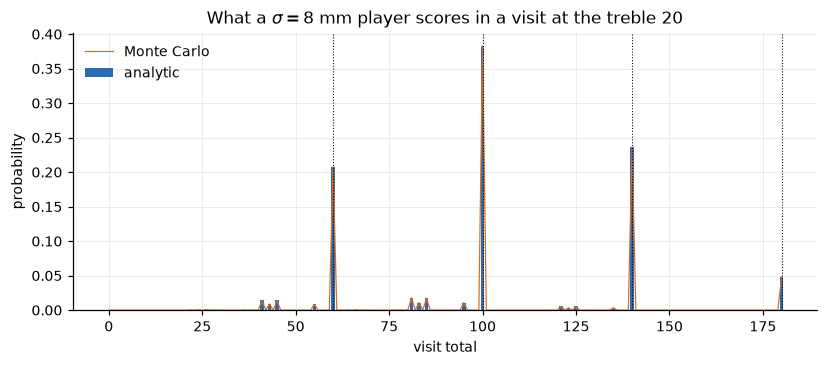

In [4]:
S8 = 8.0 ** 2 * np.eye(2)
pmf = SV.visit_pmf(T20_MM, S8)

rng = np.random.default_rng(0)
N = 400_000
land = T20_MM + 8.0 * rng.standard_normal((3 * N, 2))
col = np.rint(land[:, 0] / MM).astype(int) + CENTRE
row = np.rint(land[:, 1] / MM).astype(int) + CENTRE
ok = (row >= 0) & (row < PX) & (col >= 0) & (col < PX)
v = np.zeros(3 * N, dtype=np.int64)
v[ok] = BOARD[row[ok], col[ok]]
emp = np.bincount(v.reshape(N, 3).sum(axis=1), minlength=181) / N

print(f'analytic pmf sums to {pmf.sum():.10f}')
print(f'max |analytic - Monte Carlo| = {np.abs(pmf - emp).max():.5f}   '
      f'(Monte Carlo standard error ~ {np.sqrt(0.25/N):.5f})')
print(f'mean visit: analytic {(pmf*np.arange(181)).sum():.3f}, '
      f'Monte Carlo {v.reshape(N,3).sum(axis=1).mean():.3f}')

fig, ax = plt.subplots(figsize=(7.6, 3.4))
ax.bar(np.arange(181), pmf, width=1.0, color='#2b6cb0', label='analytic')
ax.plot(np.arange(181), emp, lw=0.8, color='#dd6b20', label='Monte Carlo')
for t, lab in [(60, '60'), (100, '100'), (140, '140'), (180, '180')]:
    ax.axvline(t, color='k', ls=':', lw=0.7)
ax.set_xlabel('visit total'); ax.set_ylabel('probability')
ax.set_title(r'What a $\sigma = 8$ mm player scores in a visit at the treble 20')
ax.legend()
fig.tight_layout()

The convolution agrees with brute force to within Monte Carlo error -- worst cell 0.00062
against a standard error of 0.00079 -- and the means match to 0.05 points in 102.

The shape of the distribution is worth a look, because it is what makes a scoresheet
informative at all. It is not a smooth bell: it is a comb, with spikes at 60, 100, 140 and
180 and gaps between them. A visit total is three draws from a discrete, wildly non-uniform
set of bed values, and the *pattern* of spikes -- how much mass sits at 140 rather than 100
-- is a much sharper fingerprint of $\sigma$ than the average alone. That is the whole
reason a three-dart average and a 180 rate can disagree about a player, which section 4
turns into a test.

## 3. What would the data buy?

The estimator works on simulated scoresheets. `scripts/calibration_recovery.py` plays legs
from a known throw, throws away everything a scoresheet would not record, and refits.

Two versions, and the difference between them is the interesting part. Letting the **aim
float** is the honest thing to do when you do not know where a player aims. Holding it at
the bed centre assumes they aim at the middle of the treble -- but it removes the aim/spread
confounding that notebook 09 found, and notebook 13 showed a single target cannot break.

In [5]:
rec = pd.read_csv(os.path.join(RESULTS, 'recovery.csv'))
g = rec.groupby(['sigma', 'legs', 'fix_mu']).agg(
    darts=('darts', 'mean'), mean_fit=('fitted', 'mean')).reset_index()
g['bias %'] = 100 * (g.mean_fit - g.sigma) / g.sigma
g['rmse'] = [np.sqrt(((rec[(rec.sigma == r.sigma) & (rec.legs == r.legs)
                          & (rec.fix_mu == r.fix_mu)].fitted - r.sigma) ** 2).mean())
             for r in g.itertuples()]
tbl = g.pivot_table(index=['sigma', 'legs', 'darts'], columns='fix_mu',
                    values=['bias %', 'rmse'])
tbl.columns = [f'{a} ({"aim fixed" if b else "aim fitted"})' for a, b in tbl.columns]
print(f"{rec.seed.nunique()} simulated players at each row")
tbl.round(2)

12 simulated players at each row


bias % (aim fitted)  bias % (aim fixed)  \
sigma legs darts                                              
6.5   25   128.00                -30.55               -5.12   
      50   269.75                -11.77                1.43   
      100  538.75                 -0.69                0.82   
      200  1082.75                -0.86                0.54   
      400  2140.25                -1.77               -0.41   
8.0   25   151.50                 -7.99               -1.90   
      50   311.50                 -0.53                0.18   
      100  611.50                 -4.70               -2.56   
      200  1236.75                 0.59                1.02   
      400  2433.75                -2.01               -1.12   
11.0  25   198.50                 -1.26               -0.39   
      50   398.00                 -1.38                0.61   
      100  800.75                 -0.99               -0.21   
      200  1590.75                -2.05                0.30   
      400  3164.75                -1.62               -0.01   

                    rmse (aim fitted)  rmse (aim fixed)  
sigma legs darts                                         
6.5   25   128.00                2.53              0.60  
      50   269.75                1.39              0.39  
      100  538.75                0.40              0.32  
      200  1082.75               0.19              0.13  
      400  2140.25               0.17              0.07  
8.0   25   151.50                1.40              0.55  
      50   311.50                0.46              0.39  
      100  611.50                0.44              0.29  
      200  1236.75               0.21              0.19  
      400  2433.75               0.24              0.19  
11.0  25   198.50                0.42              0.33  
      50   398.00                0.57              0.48  
      100  800.75                0.34              0.21  
      200  1590.75               0.43              0.21  
      400  3164.75               0.31              0.16

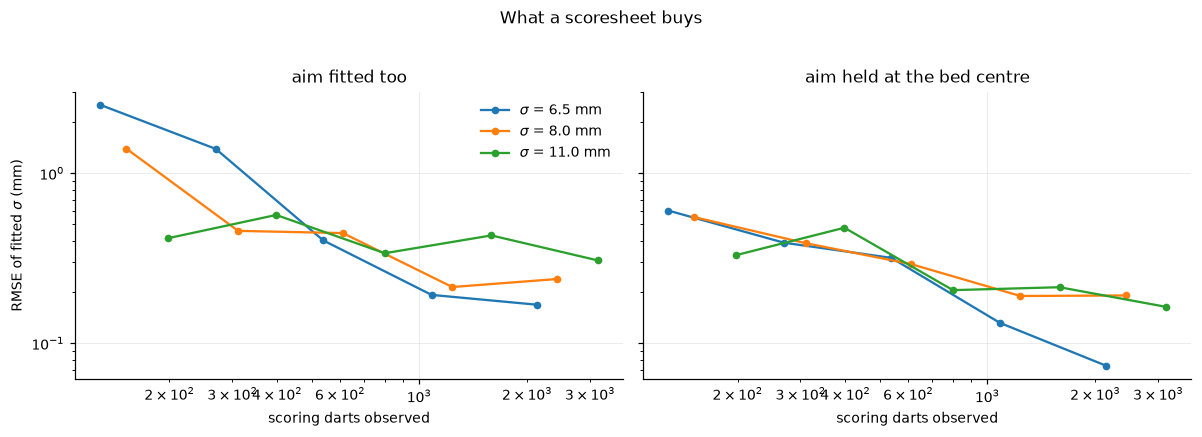

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, fix in zip(axes, (False, True)):
    for s, sub in g[g.fix_mu == fix].groupby('sigma'):
        ax.plot(sub.darts, sub.rmse, 'o-', ms=4, label=f'$\\sigma$ = {s} mm')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('scoring darts observed')
    ax.set_title('aim held at the bed centre' if fix else 'aim fitted too')
axes[0].set_ylabel('RMSE of fitted $\\sigma$ (mm)')
axes[0].legend()
fig.suptitle('What a scoresheet buys', y=1.03)
fig.tight_layout()

**A scoresheet does measure a player, and the aim assumption matters more than the sample
size.**

Reading the aim-fitted columns first: at 128 darts an elite player's $\sigma$ comes back
**30% low**, with an RMSE of 2.5 mm on a true value of 6.5. That is not sampling noise, it
is notebook 09's confounding arriving exactly as predicted -- from a single target, an
unluckily tight group of darts is equally well explained by a *tighter thrower aiming
somewhere else*, and the fit takes that explanation. The fitted aim in those runs drifts
several millimetres off the bed centre, which is the tell.

Holding the aim at the bed centre removes the freedom and the problem with it: the same 128
darts give a 5% bias and an RMSE of 0.60 mm, a **four-fold improvement**. The advantage
persists but shrinks with data, and by a couple of thousand darts both fits are within 2%.

Two things follow for real data.

**Fit both, and treat disagreement as information.** With enough darts the aim-fitted
version is reliable, so it can be used to check the assumption rather than merely assumed
away. If a player's fitted aim comes back 5 mm from the bed centre at 3,000 darts, that is
either a genuine pull or a broken model, and both are worth knowing.

**The precision matches what notebook 09 predicted for this target.** At 539 darts the
aim-fitted RMSE is 0.40 mm against a Fisher prediction of 0.39 -- so the estimator is
efficient, and the pessimism about the treble 20 is a property of the target rather than of
this particular fit. Roughly 2,000 scoring darts, which is a season of televised darts for
one player, gets an elite player to about 0.2 mm.

## 4. One sigma has to explain everything at once

Here is where a calibration stops being a curve-fit and becomes a test.

The model gives a player **one** parameter for their scoring. That single number fixes their
three-dart average, their 180 rate, their 140+ rate *and* -- through the same covariance,
60 mm further out on the board -- how often they hit a double. Those are four numbers
published for every professional match played. There is no freedom to fit them separately.

In [7]:
rows = []
for s in (5.0, 6.0, 6.5, 7.0, 8.0, 9.0, 10.0, 12.0, 14.0, 16.0, 20.0):
    S = s ** 2 * np.eye(2)
    st = SV.statistics(T20_MM, S)
    rows.append({'sigma (mm)': s,
                 '3-dart average': st['three_dart_average'],
                 '180 %': 100 * st['p_180'],
                 '140+ %': 100 * st['p_140_plus'],
                 '100+ %': 100 * st['p_100_plus'],
                 'D20 %': 100 * DA.hit_probability(S, 20),
                 'D16 %': 100 * DA.hit_probability(S, 16),
                 'bull %': 100 * DA.hit_probability(S, 25)})
pred = pd.DataFrame(rows).set_index('sigma (mm)')
pred.round(2)

,3-dart average,180 %,140+ %,100+ %,D20 %,D16 %,bull %
sigma (mm),,,,,,,
5.0,128.71,18.81,60.75,92.03,57.16,57.17,54.82
6.0,118.41,11.71,47.88,85.61,49.09,49.18,42.41
6.5,113.88,9.34,42.26,81.77,45.79,45.90,37.52
7.0,109.64,7.48,37.16,77.57,42.87,43.00,33.34
8.0,101.82,4.85,28.44,68.45,37.95,38.09,26.69
9.0,94.73,3.18,21.55,59.10,33.94,34.08,21.76
10.0,88.32,2.11,16.25,50.23,30.58,30.69,18.03
12.0,77.32,0.97,9.27,35.34,25.16,25.23,12.89
14.0,68.49,0.47,5.41,24.63,20.94,20.97,9.65


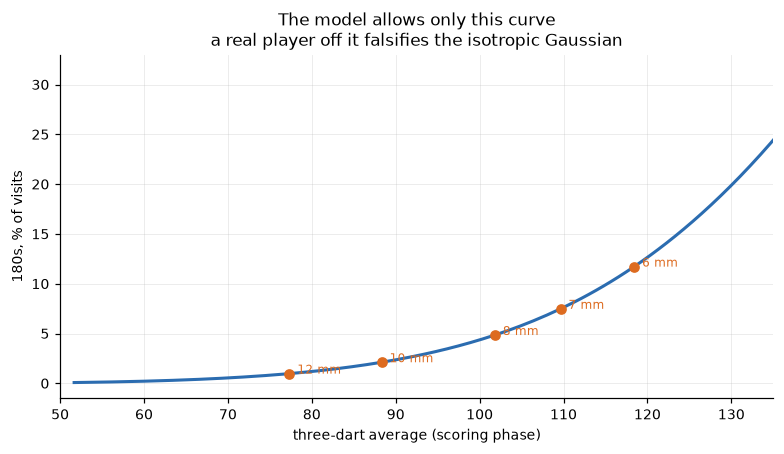

In [8]:
# the falsifiable curve: a player's average and their 180 rate are not free of each other
fine = np.arange(4.0, 20.01, 0.1)
avg, p180 = [], []
for s in fine:
    st = SV.statistics(T20_MM, s ** 2 * np.eye(2))
    avg.append(st['three_dart_average']); p180.append(100 * st['p_180'])

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(avg, p180, lw=2, color='#2b6cb0')
for s in (6.0, 7.0, 8.0, 10.0, 12.0):
    st = SV.statistics(T20_MM, s ** 2 * np.eye(2))
    ax.plot(st['three_dart_average'], 100 * st['p_180'], 'o', ms=6, color='#dd6b20')
    ax.annotate(f'  {s:.0f} mm', (st['three_dart_average'], 100 * st['p_180']),
                fontsize=8, color='#dd6b20')
ax.set_xlabel('three-dart average (scoring phase)')
ax.set_ylabel('180s, % of visits')
ax.set_title('The model allows only this curve\n'
             'a real player off it falsifies the isotropic Gaussian')
ax.set_xlim(50, 135)
fig.tight_layout()

This table is the reason to do any of this, and the curve underneath it is the reason the
exercise can fail.

The model has **one** free parameter for a player's scoring. Fix it and everything else is
determined: a $\sigma = 8$ mm player must average 101.8, must hit a 180 in 4.85% of visits,
must hit 140+ in 28.4%, and -- through the same covariance, 63 mm further out on the board
-- must hit the double 20 with probability 0.379. There is no slack anywhere.

The curve makes the sharpest version of this concrete. A three-dart average and a 180 rate
are two numbers published for every professional match ever played, and the model permits
only **one** pairing of them. A player who averages 102 must hit 180s in about 5% of visits.
If real players average 102 and hit 7%, they are not on the curve, and the isotropic
Gaussian is wrong in a way no amount of refitting $\sigma$ can absorb.

Note also what happens at the far right: the model needs $\sigma$ near 5 mm to average 128,
and no human averages 128 over a match. So the curve's upper reach is a region the model can
describe and reality does not occupy, which is itself worth remembering when it fits
suspiciously well somewhere.

In [9]:
# the diagnostic, run on hypothetical players: each statistic implies its own sigma
examples = {
    'consistent (sigma 8mm exactly)':
        {k: v for k, v in SV.statistics(T20_MM, 8.0 ** 2 * np.eye(2)).items()
         if k in ('three_dart_average', 'p_180', 'p_140_plus')},
    'averages 102 but hits 7% 180s':
        {'three_dart_average': 102.0, 'p_180': 0.07, 'p_140_plus': 0.30},
    'averages 95 but hits 2% 180s':
        {'three_dart_average': 95.0, 'p_180': 0.02, 'p_140_plus': 0.20},
}
rows = []
for name, stats in examples.items():
    implied = aggregate_consistency(stats, board_pixels=PX, board=BOARD)
    r = {'player': name}
    r.update({k: v for k, v in implied.items()})
    vals = [v for v in implied.values() if np.isfinite(v)]
    r['spread (mm)'] = max(vals) - min(vals) if len(vals) > 1 else np.nan
    rows.append(r)
print('sigma implied by each statistic separately')
pd.DataFrame(rows).set_index('player').round(2)

sigma implied by each statistic separately


,three_dart_average,p_180,p_140_plus,spread (mm)
player,,,,
consistent (sigma 8mm exactly),8.00,8.00,8.00,0.00
averages 102 but hits 7% 180s,7.98,7.15,7.80,0.82
averages 95 but hits 2% 180s,8.96,10.14,9.26,1.18


The diagnostic turns "the model does not fit" into "the model fails *this way*", by asking
what $\sigma$ each statistic would imply on its own.

A player the model can actually produce comes back perfectly consistent -- all three
statistics imply 8.00 mm, which is the round trip working. The two hypothetical players do
not. One who averages 102 while hitting 7% 180s implies 7.98 mm from the average and 7.15 mm
from the 180 rate: a **0.82 mm disagreement**, and in a specific direction -- their big
visits are more frequent than their average can explain, so their darts cluster more than a
Gaussian allows. The other is the mirror image, 1.18 mm the other way: plenty of scoring but
not enough maximums, a player whose darts spray more than their average suggests.

Both are the signature of a **heavier or lighter tail than a Gaussian**, and the sign says
which. That is a far more useful failure than a bad fit statistic, because it points at the
repair.

## 5. The sharpest test is the cheapest data

The scoring statistics test the model at one point on the board. The **doubles** test it
somewhere else entirely -- a different radius, a different bed shape, and twenty different
orientations.

And the model makes a startlingly strong claim about them. An isotropic throw aimed at the
centre of a double bed hits it with a probability that depends only on the bed's *size*, and
every double bed is the same size. So **every double should be equally hard**.

Notebook 12 showed why that claim is fragile: a bed is 8 mm deep and 52 mm long, so which
of those two dimensions your error runs into depends entirely on where the bed sits. A
player whose group is taller than it is wide should find the side doubles much easier than
the top and bottom ones.

                  min    max  spread (pts)  ratio
model                                            
isotropic 8mm   37.95  38.17          0.22   1.01
leaning 45 deg  28.50  47.40         18.90   1.66
tall 11x6mm     28.14  48.27         20.13   1.72


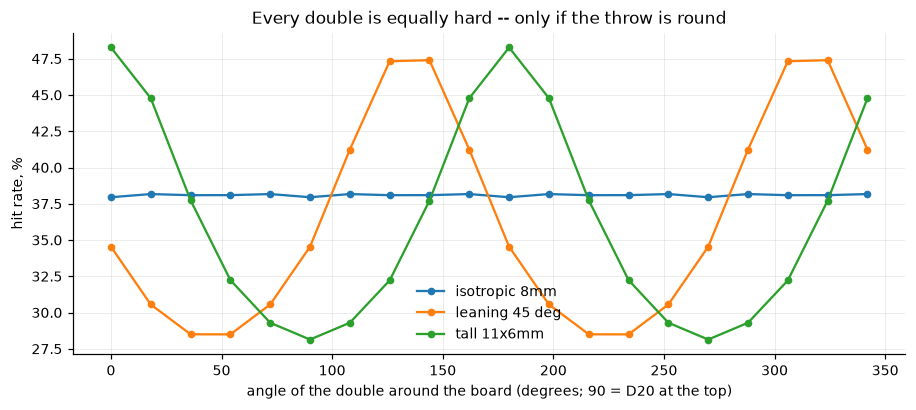

In [10]:
from darts.throw_shape import rotated_sigma

NUMS = [20, 1, 18, 4, 13, 6, 10, 15, 2, 17, 3, 19, 7, 16, 8, 11, 14, 9, 12, 5]
ANGLE = {n: (90 - 18 * i) % 360 for i, n in enumerate(NUMS)}

models = {'isotropic 8mm': 8.0 ** 2 * np.eye(2),
          'tall 11x6mm': rotated_sigma(11.0, 6.0, 90.0),
          'leaning 45 deg': rotated_sigma(11.0, 6.0, 45.0)}
rows = []
for name, S in models.items():
    for n in NUMS:
        rows.append({'model': name, 'double': n, 'angle': ANGLE[n],
                     'hit %': 100 * DA.hit_probability(S, n)})
dbl = pd.DataFrame(rows)
summary = dbl.groupby('model')['hit %'].agg(['min', 'max'])
summary['spread (pts)'] = summary['max'] - summary['min']
summary['ratio'] = summary['max'] / summary['min']
print(summary.round(2).to_string())

fig, ax = plt.subplots(figsize=(8.4, 3.8))
for name, sub in dbl.groupby('model'):
    sub = sub.sort_values('angle')
    ax.plot(sub.angle, sub['hit %'], 'o-', ms=4, label=name)
ax.set_xlabel('angle of the double around the board (degrees; 90 = D20 at the top)')
ax.set_ylabel('hit rate, %')
ax.set_title('Every double is equally hard -- only if the throw is round')
ax.legend()
fig.tight_layout()

**Every double is equally hard -- 37.95% to 38.17%, a spread of 0.22 points across all
twenty.** That is not an approximation; it is what an isotropic throw *must* say. A double
bed is the same size wherever it sits, a round error cloud has no preferred direction, so
the only thing left to vary is the neighbouring beds, which do not affect whether you hit
the one you aimed at.

It is also, on its face, implausible. And the alternatives show how implausible: give the
same player a group taller than it is wide, holding the ellipse area fixed, and the spread
goes from 0.22 points to **20 points** -- 28% at the double 20 at the top of the board
against 48% at the double 6 on the side. A 45-degree lean gives nearly as much, rotated.

The mechanism is notebook 12's, seen from the checkout end. A bed is 8 mm deep and 52 mm
long. At the top of the board a vertical error runs into the 8 mm; on the side it runs along
the 52 mm. A player whose misses are mostly vertical therefore finds the side doubles far
easier, and the model can express this perfectly well -- it simply predicts it does not
happen, for a round thrower.

So **per-double checkout rates are the sharpest test of the model available**, and they test
the assumption that has never been checked against a human: that a real throw is round.

In [11]:
# how many attempts does the test need?
from statistics import NormalDist
z = NormalDist().inv_cdf(0.975) + NormalDist().inv_cdf(0.80)

rows = []
base = 8.0
for ratio in (1.0, 1.1, 1.25, 1.5, 1.75, 2.0):
    minor, major = base / np.sqrt(ratio), base * np.sqrt(ratio)
    S = rotated_sigma(major, minor, 90.0)          # equal ellipse area throughout
    p_top = DA.hit_probability(S, 20)
    p_side = DA.hit_probability(S, 6)
    d = abs(p_top - p_side)
    pbar = 0.5 * (p_top + p_side)
    n = 2 * pbar * (1 - pbar) * (z / d) ** 2 if d > 1e-9 else np.inf
    rows.append({'axis ratio': ratio, 'major (mm)': major, 'minor (mm)': minor,
                 'D20 %': 100 * p_top, 'D6 %': 100 * p_side,
                 'attempts at each': n})
print('detecting a tall throw from checkout rates alone (80% power, alpha 0.05)')
pd.DataFrame(rows).set_index('axis ratio').round(1)

detecting a tall throw from checkout rates alone (80% power, alpha 0.05)


,major (mm),minor (mm),D20 %,D6 %,attempts at each
axis ratio,,,,,
1.00,8.0,8.0,38.0,38.0,inf
1.10,8.4,7.6,36.3,39.6,3417.3
1.25,8.9,7.2,34.2,41.9,627.1
1.50,9.8,6.5,31.4,45.3,193.2
1.75,10.6,6.0,29.2,48.1,103.8
2.00,11.3,5.7,27.4,50.6,69.4


And the test is cheap. Comparing the double 20 against the double 6 -- the top of the board
against the side, the two ends of the effect -- needs about **190 attempts at each** to
detect a 1.5:1 axis ratio, and 104 for 1.75:1.

Put that next to what the same question costs elsewhere. Notebook 16 needed 93 darts at the
*bull* to pin a lean to $\pm 0.1$, and that is a deliberate drill nobody plays. A hundred
attempts at each of two doubles is a season of one professional's checkout attempts, already
recorded, already published.

The test does get expensive as the throw approaches round: a 1.1:1 ratio needs 3,400
attempts at each. But that is the right behaviour -- a nearly round player *is* nearly
described by the round model, so failing to reject is not a failure.

Two honest caveats. Real attempts are not spread evenly over the doubles: the 20, 16 and 10
get most of them, and the pairs this test wants may be thin. And a player who has practised
the double 20 a thousand times more than the double 3 will differ between them for reasons
that have nothing to do with the shape of their throw -- which is aim-dependent accuracy,
the other open item, and is confounded with anisotropy here. The clean version of the test
compares doubles at **similar practice frequency and different angles**, which is a
constraint on which pairs to use rather than an objection.

The analysis above is written and tested; what it lacks is data. In priority order, and with
what each unlocks:

| what to collect | unlocks | how much is enough |
|---|---|---|
| **Checkout attempts and hits, broken down by which double** | the anisotropy test of section 5 -- the sharpest thing here | ~200 attempts at each of two doubles 90 degrees apart |
| **Per-visit totals with the score before each visit** | the full likelihood of section 3 | ~2,000 scoring darts per player for $\pm 0.2$ mm |
| **Three-dart average *and* 180 / 140+ rates, per player** | the consistency diagnostic of section 4 | one season per player |
| Per-dart bed-by-bed records | everything above, and the aim-dependent accuracy question | rare; take it if it exists |

Two fields are worth insisting on because they are routinely dropped. A visit total is
useless without the **score before the visit**, since that is what decides whether the visit
was in the pure scoring phase. And a checkout percentage is useless without its
**denominator** -- a rate without a sample size carries no weight in any of the tests above.

## Verdict

**The model can be calibrated against ordinary match scores, and more usefully, it can be
refuted by them.**

1. *Can the aim be recovered?* **Yes, in the pure scoring phase, with no circularity.** Above
   a remaining score of 250 the optimal aim is the treble 20 for every ability, so the aim is
   known rather than inferred, all three darts of a visit are i.i.d., and a visit total is
   an exact three-fold convolution. The floor is 250 rather than 182 because a good player
   diverts to the treble 19 to set up a finish, and forcing them back costs up to 0.12
   visits.
2. *What would the data buy?* **About 2,000 scoring darts gets an elite player to
   $\pm 0.2$ mm** -- a season of televised darts. But the aim must be held at the bed centre
   to get there: letting it float reproduces notebook 09's confounding and returns a
   $\sigma$ 30% low at small samples, with four times the RMSE.
3. *What could go wrong -- usefully?* **One $\sigma$ has to explain the average, the 180
   rate and the checkout rate at once,** and there is no reason it should. The consistency
   diagnostic reports the disagreement in millimetres and its sign says whether the player's
   darts cluster more or less than a Gaussian allows.

The result I did not expect is that **the cheapest data is the sharpest test**. An isotropic
throw says all twenty doubles are equally hard, to within 0.22 percentage points. A throw
with a 1.5:1 axis ratio says they vary by 14 points. Distinguishing these needs about 200
attempts at each of two doubles -- less data than any other question in this project, testing
the assumption that has gone unexamined the longest.

### What this leaves

* **No real data.** Everything above is machinery and power analysis. The estimators are
  validated against simulated players whose $\sigma$ we chose, which proves they work and
  proves nothing about darts.
* **The scoring phase only.** Fitting from the checkout phase would need the player's actual
  chart, and real players do not follow the model's. Notebook 05 measured that gap; using it
  as a likelihood would mean modelling what players *do* rather than what they should.
* **Anisotropy and practice are confounded in the double test.** A player better at the
  double 20 than the double 3 might have a tall group or might simply have thrown at the 20
  ten thousand more times. Separating them needs pairs matched on practice frequency, or the
  per-region model of the roadmap's §1.1.
* **The Gaussian itself is untested.** Every failure mode above is diagnosed *within* the
  Gaussian family, as a wrong $\Sigma$. A real throw might have heavier tails -- the
  occasional badly released dart -- and the consistency diagnostic would report that as an
  inconsistent $\sigma$ without ever naming the real cause.